#Car price prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df=pd.read_csv('cardekho_imputated.csv')

In [3]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [5]:
print(df.duplicated().sum())

167


In [6]:
df=df.drop_duplicates()

In [7]:
#check the null values
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  object 
 1   brand              15244 non-null  object 
 2   model              15244 non-null  object 
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  object 
 6   fuel_type          15244 non-null  object 
 7   transmission_type  15244 non-null  object 
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
 12  selling_price      15244 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [9]:
#carname and brand are not required since the model is enough
df = df.drop(columns=['car_name', 'brand'])

In [10]:
df.head()

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


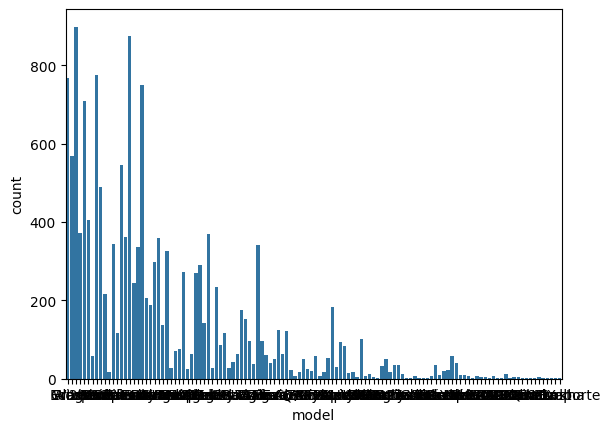

In [11]:
sns.countplot(x='model', data=df)
plt.show()

In [12]:
#check the unique values
print(df['model'].nunique())
print(df['seller_type'].unique())
print(df['fuel_type'].unique())
print(df['transmission_type'].unique())

120
['Individual' 'Dealer' 'Trustmark Dealer']
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
['Manual' 'Automatic']


In [13]:
df = pd.get_dummies(
    df,
    columns=['model', 'seller_type', 'fuel_type','transmission_type'],
    drop_first=True
)

In [14]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,model_5,model_6,model_7,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,True,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [15]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [16]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,model_5,model_6,model_7,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0,0,0,...,0,0,0,1,0,0,0,0,1,1
1,5,20000,18.90,1197,82.00,5,550000,0,0,0,...,0,0,0,1,0,0,0,0,1,1
2,11,60000,17.00,1197,80.00,5,215000,0,0,0,...,0,1,0,1,0,0,0,0,1,1
3,9,37000,20.92,998,67.10,5,226000,0,0,0,...,0,0,0,1,0,0,0,0,1,1
4,6,30000,22.77,1498,98.59,5,570000,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [17]:
# Import Regression Models

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:
# Independent variables
X = df.drop('selling_price', axis=1)

# Dependent variable
y = df['selling_price']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Dictionary of Models
models={

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "Elastic Net": ElasticNet(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42)

}

In [22]:
# Store Results

results = []

# Loop through every model

for name, model in models.items():

    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    else:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

In [23]:
# Comparison Table

comparison = pd.DataFrame(

    results,

    columns=["Model","MAE","MSE","RMSE","R2 Score"]

)

comparison.sort_values(by="R2 Score", ascending=False, inplace=True)

comparison

,Model,MAE,MSE,RMSE,R2 Score
5,Random Forest,100856.647249,7.086371e+10,266202.376594,0.883452
6,Gradient Boosting,125712.425137,9.122606e+10,302036.516808,0.849962
4,Decision Tree,125218.481469,9.780689e+10,312740.927659,0.839139
0,Linear Regression,169782.583565,1.236764e+11,351676.486429,0.796592
2,Lasso Regression,169782.439482,1.236795e+11,351680.933416,0.796587
1,Ridge Regression,169780.944022,1.237065e+11,351719.382280,0.796542
3,Elastic Net,172326.180023,1.450380e+11,380838.603741,0.761459


#Hyperparameter tunning based on best model

#Random forest regressor

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV R2:", grid_rf.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2: 0.8876202664586115


In [25]:
from sklearn.metrics import r2_score

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

print("Random Forest Test R²:", r2_score(y_test, rf_pred))

Random Forest Test R²: 0.8787825211522208


#Gradient Boosting

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters:", grid_gb.best_params_)
print("Best CV R2:", grid_gb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2: 0.8751447269272296


In [27]:
best_gb = grid_gb.best_estimator_
gb_pred = best_gb.predict(X_test)

print("Gradient Boosting Test R²:", r2_score(y_test, gb_pred))

Gradient Boosting Test R²: 0.8572805538451075


In [28]:
new_data = pd.DataFrame(0, index=[0], columns=X.columns)

new_data['vehicle_age'] = 5
new_data['km_driven'] = 30000
new_data['mileage'] = 18.5
new_data['engine'] = 1197
new_data['max_power'] = 82
new_data['seats'] = 5

new_data['model_i20'] = 1
new_data['seller_type_Individual'] = 1
new_data['fuel_type_Petrol'] = 1
new_data['transmission_type_Manual'] = 1

prediction = best_rf.predict(new_data)

print(f"Predicted Selling Price: ₹{prediction[0]:,.2f}")

Predicted Selling Price: ₹558,580.10
